In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression

#input data
x=np.array([[1],[2],[3],[4],[5]])
y=np.array([3,5,7,9,11])

#create model
model=LinearRegression()

#Train Model
model.fit(x,y)

#prediction
prediction=model.predict([[6]])

print("Prediction:",prediction)

Prediction: [13.]


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Sample Data
df = pd.DataFrame({
    "Experience":[1,2,3,4,5,6,7,8],
    "Salary":[30000,35000,40000,50000,60000,65000,70000,80000]
})

X = df[["Experience"]]
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create Model
model = Lasso(alpha=100)

# Train
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Coefficient :", model.coef_)
print("Intercept :", model.intercept_)
print("R2 Score :", r2_score(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))

Coefficient : [7182.]
Intercept : 21484.0
R2 Score : 0.9980024888888889
MSE : 449440.0


Weight : [2.10204281]
Bias : [0.62583395]
Prediction for x=6 : [13.23809082]


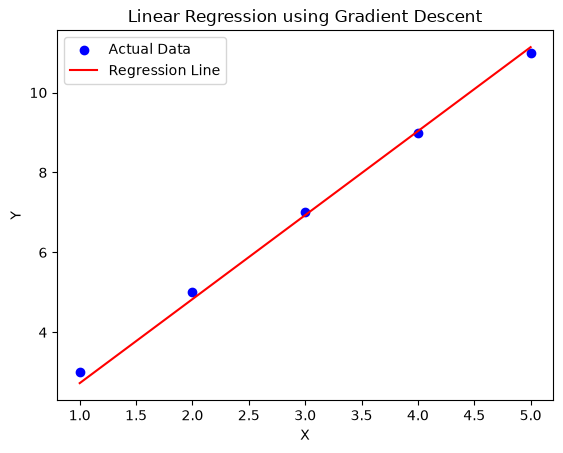

In [2]:
import numpy as np
from sklearn.linear_model import SGDRegressor
import matplotlib.pyplot as plt

# Sample Data
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([3, 5, 7, 9, 11])

# Model using Gradient Descent
model = SGDRegressor(
    max_iter=1000,
    learning_rate='constant',
    eta0=0.01,
    random_state=42
)

# Train Model
model.fit(X, y)

# Prediction
prediction = model.predict([[6]])

print("Weight :", model.coef_)
print("Bias :", model.intercept_)
print("Prediction for x=6 :", prediction)

# Plot
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression using Gradient Descent")
plt.legend()
plt.show()

In [3]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

# Actual values
y_true = [50, 60, 70, 80]

# Predicted values
y_pred = [55, 58, 75, 78]

# MAE
mae = mean_absolute_error(y_true, y_pred)

# MSE
mse = mean_squared_error(y_true, y_pred)

# RMSE
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

MAE : 3.5
MSE : 14.5
RMSE: 3.8078865529319543


In [4]:
#Step 1: Import Required Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [5]:
# Step 2: Define the Lasso Regression Class
# __init__(): Initializes learning rate, number of iterations and L1 penalty parameter.
# fit(): Trains the model by initializing weights and repeatedly updating them using gradient descent.
# update_weights(): Computes gradients with L1 penalty and updates the weight and bias values.
# predict(): Generates predicted values using the learned weights and bias.

In [6]:
class LassoRegression():
    def __init__(self, learning_rate, iterations, l1_penalty):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.l1_penalty = l1_penalty

    def fit(self, X, Y):
        self.m, self.n = X.shape
        self.W = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.Y = Y

        for i in range(self.iterations):
            self.update_weights()
        return self

    def update_weights(self):
        Y_pred = self.predict(self.X)
      
        dW = np.zeros(self.n)
        for j in range(self.n):
            if self.W[j] > 0:
                dW[j] = (-2 * (self.X[:, j]).dot(self.Y - Y_pred) +
                         self.l1_penalty) / self.m
            else:
                dW[j] = (-2 * (self.X[:, j]).dot(self.Y - Y_pred) -
                         self.l1_penalty) / self.m

        db = -2 * np.sum(self.Y - Y_pred) / self.m

        self.W = self.W - self.learning_rate * dW
        self.b = self.b - self.learning_rate * db
        return self

    def predict(self, X):
        return X.dot(self.W) + self.b

In [7]:
# Step 3: Load the Dataset


In [10]:
df = pd.read_csv("Experience-Salary.csv")
df.head()

,Years of Experience,Salary
0,4.941931,9372.711912
1,9.069024,23015.300694
2,8.109230,17039.178915
3,9.807933,19905.398181
4,6.274945,17033.827082


In [11]:
# Step 4: Prepare and Split the Dataset
# Here we separate the feature and target variables, standardize the input data and split the dataset for training and testing.

# X contains the input feature (Years of Experience) and Y contains the target variable (Salary).
# StandardScaler() is applied to normalize the feature values before training.
# train_test_split() divides the data into training and testing sets to evaluate model performance.

In [12]:
X = df.iloc[:, :-1].values
Y = df.iloc[:, 1].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=1/3, random_state=0)

In [13]:
# Here we initialize the Lasso Regression model with the specified learning rate, number of iterations and L1 penalty. The model is then trained using the training dataset to learn the relationship between experience and salary.

model = LassoRegression(iterations=1000, learning_rate=0.01, l1_penalty=500)
model.fit(X_train, Y_train)

In [14]:
# Step 6: Model Evaluation and Output
# In this step, we generate predictions using the trained model and examine the learned parameters.

# model.predict(X_test) is used to predict salary values and compare them with the actual test values.
# The trained weight (W) and bias (b) are printed to observe how the model has learned the relationship between experience and salary.



Y_pred = model.predict(X_test)
print("Predicted values: ", np.round(Y_pred[:3], 2))
print("Real values:      ", Y_test[:3])
print("Trained W:        ", round(model.W[0], 2))
print("Trained b:        ", round(model.b, 2))

Predicted values:  [35539.41 18099.76 43796.5 ]
Real values:       [42328.57198221 16443.83637617 44375.48684823]
Trained W:         11516.31
Trained b:         26129.99


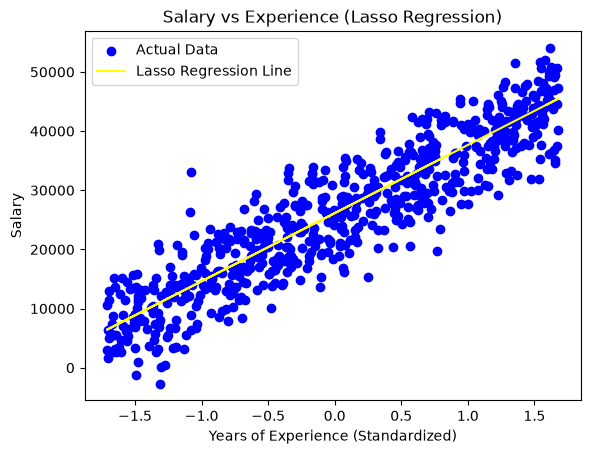

In [15]:
# Step 7: Visualize the Regression Results
# Now we plot the actual salaries against the predicted values to visualize how well the Lasso Regression model fits the data.


plt.scatter(X_test, Y_test, color='blue', label='Actual Data')
plt.plot(X_test, Y_pred, color='yellow', label='Lasso Regression Line')
plt.title('Salary vs Experience (Lasso Regression)')
plt.xlabel('Years of Experience (Standardized)')
plt.ylabel('Salary')
plt.legend()
plt.show()